Spatial Cross-Validation Evaluation
Evaluates exp307/exp308/exp309 using leave-one-region-out spatial CV
Regions based on HUC4 groupings across MN peatland zones

In [1]:
# CONFIG
EXP_TO_EVAL  = 'exp308'   # change to exp307, exp309_stage2_depth, etc.
BASE_DIR     = '/scratch.global/ocon0444/peat_modeling'
N_TREES      = 200
RANDOM_STATE = 42

# Dataset to use — must match the experiment
COVAR_CSV  = f'{BASE_DIR}/00_data/processed/depb_features_extracted.csv'
TARGET_COL = 'depth_class'   # or 'peat_binary' for binary experiments

# Depth bins to apply — match the experiment you're evaluating
BINS   = [-1, 0.5, 100, 300, float('inf')]
LABELS = [0, 1, 2, 3]

In [2]:
# Spatial region definitions
# Based on HUC4 watersheds grouped into ecological regions
# Assign each depb point to a region via lat/long → HUC lookup
# Using coordinate bounding boxes as practical proxy for MN peat zones

SPATIAL_REGIONS = {
    'RedLake_NW': {
        'desc': 'Red Lake Peatland + Upper Red River (flattest, most peat)',
        'huc4s': ['0902'],
        'approx_bounds': {'xmin': -97.5, 'xmax': -94.5, 'ymin': 47.0, 'ymax': 49.5}
    },
    'BWCA_NE': {
        'desc': 'Boundary Waters / Rainy Lake boreal (lake-dominated)',
        'huc4s': ['0401', '0402'],
        'approx_bounds': {'xmin': -94.0, 'xmax': -89.5, 'ymin': 47.5, 'ymax': 49.5}
    },
    'NorthCentral': {
        'desc': 'Leech Lake / Upper Mississippi headwaters',
        'huc4s': ['0701', '0702', '0703'],
        'approx_bounds': {'xmin': -95.5, 'xmax': -92.5, 'ymin': 46.5, 'ymax': 48.0}
    },
    'CentralTransition': {
        'desc': 'Central MN transition zone / St Croix',
        'huc4s': ['0703', '0704', '0706', '0708'],
        'approx_bounds': {'xmin': -95.0, 'xmax': -92.0, 'ymin': 45.0, 'ymax': 46.5}
    },
    'Southern': {
        'desc': 'Southern MN agricultural / mostly mineral',
        'huc4s': ['0708', '1017', '1023'],
        'approx_bounds': {'xmin': -97.0, 'xmax': -91.0, 'ymin': 43.5, 'ymax': 45.0}
    }
}

In [3]:
# Imports
import pandas as pd
import numpy as np
import pickle, os, json
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = f'{BASE_DIR}/05_results/{EXP_TO_EVAL}_spatial_cv'
os.makedirs(RESULTS_DIR, exist_ok=True)

In [4]:
# Load data
print(f'Loading {COVAR_CSV}...')
df = pd.read_csv(COVAR_CSV, low_memory=False)
print(f'Shape: {df.shape}')

# Assign depth classes
df[TARGET_COL] = pd.cut(df['depb'], bins=BINS, labels=LABELS).astype(int)

Loading /scratch.global/ocon0444/peat_modeling/00_data/processed/depb_features_extracted.csv...
Shape: (45878, 150)


In [5]:
# Assign spatial regions by lat/long bounding box
def assign_region(lat, lon):
    for region, cfg in SPATIAL_REGIONS.items():
        b = cfg['approx_bounds']
        if b['xmin'] <= lon <= b['xmax'] and b['ymin'] <= lat <= b['ymax']:
            return region
    return 'Unassigned'

df['spatial_region'] = df.apply(lambda r: assign_region(r['lat'], r['long']), axis=1)

print('\nPoints per spatial region:')
region_counts = df['spatial_region'].value_counts()
print(region_counts.to_string())


Points per spatial region:
spatial_region
Southern             17840
BWCA_NE               7816
NorthCentral          6165
CentralTransition     5797
Unassigned            4842
RedLake_NW            3418


In [6]:
# Check peat coverage per region
print('\nPeat points (depb>0) per region:')
for region in SPATIAL_REGIONS:
    sub = df[df['spatial_region'] == region]
    peat = (sub['depb'] > 0).sum()
    print(f'  {region}: {len(sub):,} total, {peat:,} peat ({peat/len(sub)*100:.1f}%)')


Peat points (depb>0) per region:
  RedLake_NW: 3,418 total, 946 peat (27.7%)
  BWCA_NE: 7,816 total, 3,658 peat (46.8%)
  NorthCentral: 6,165 total, 3,890 peat (63.1%)
  CentralTransition: 5,797 total, 1,133 peat (19.5%)
  Southern: 17,840 total, 179 peat (1.0%)


In [7]:
# Define features
METADATA_COLS = ['lat', 'long', 'depb', TARGET_COL, 'spatial_region']
PEAT_MAP_COLS = [
    'mn_nwi_cowardin_0', 'mn_nwi_cowardin_1', 'mn_nwi_cowardin_2',
    'histosols_10m_0', 'histosols_10m_1',
    'MN_organic_soils_classified_0', 'MN_organic_soils_classified_1',
    'MN_organic_soils_classified_2', 'MN_organic_soils_classified_3',
    'MN_organic_soils_classified_5', 'MN_organic_soils_classified_6',
    'MN_organic_soils_classified_7', 'MN_organic_soils_classified_8',
    'MN_ANY_organic_component_0', 'MN_ANY_organic_component_1',
    'gNATSGO_MN_26915', 'npc_peatland_indicator_10m',
    'wetnessIndex',
]
EXCLUDE = set(METADATA_COLS + PEAT_MAP_COLS)
feature_cols = [c for c in df.columns if c not in EXCLUDE]
print(f'\nFeatures: {len(feature_cols)}')

df_model = df[feature_cols + [TARGET_COL, 'spatial_region']].dropna(subset=feature_cols + [TARGET_COL])
print(f'Rows after NaN drop: {len(df_model):,}')


Features: 130
Rows after NaN drop: 45,877


In [8]:
# Spatial leave-one-region-out CV
regions = [r for r in SPATIAL_REGIONS if r in df_model['spatial_region'].values]
cv_results = []
all_y_true, all_y_pred, all_regions = [], [], []

print(f'\nRunning leave-one-region-out CV ({len(regions)} folds)...')

for test_region in regions:
    train_mask = df_model['spatial_region'] != test_region
    test_mask  = df_model['spatial_region'] == test_region

    X_train = df_model.loc[train_mask, feature_cols].values.astype(np.float32)
    y_train = df_model.loc[train_mask, TARGET_COL].values
    X_test  = df_model.loc[test_mask,  feature_cols].values.astype(np.float32)
    y_test  = df_model.loc[test_mask,  TARGET_COL].values

    if len(np.unique(y_test)) < 2:
        print(f'  {test_region}: skipping (only 1 class in test set)')
        continue

    print(f'\n  Test region: {test_region} ({len(X_test):,} points)')
    print(f'  Train:       {len(X_train):,} points')

    clf = RandomForestClassifier(
        n_estimators=N_TREES, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cv_results.append({
        'region': test_region,
        'n_test': len(y_test),
        'n_train': len(X_train),
        'acc': acc,
        'f1': f1,
        'classes_in_test': sorted(np.unique(y_test).tolist())
    })
    print(f'  Acc={acc:.4f}  F1={f1:.4f}')

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_regions.extend([test_region] * len(y_test))


Running leave-one-region-out CV (5 folds)...

  Test region: RedLake_NW (3,418 points)
  Train:       42,459 points
  Acc=0.8116  F1=0.7842

  Test region: BWCA_NE (7,816 points)
  Train:       38,061 points
  Acc=0.6242  F1=0.4947

  Test region: NorthCentral (6,165 points)
  Train:       39,712 points
  Acc=0.6689  F1=0.5848

  Test region: CentralTransition (5,797 points)
  Train:       40,080 points
  Acc=0.8359  F1=0.7748

  Test region: Southern (17,840 points)
  Train:       28,037 points
  Acc=0.9900  F1=0.9850


In [9]:
# Results summary
cv_df = pd.DataFrame(cv_results)
print('\n' + '='*60)
print('SPATIAL CV RESULTS')
print('='*60)
print(cv_df[['region', 'n_test', 'acc', 'f1']].to_string(index=False))
print(f'\nMean Accuracy: {cv_df["acc"].mean():.4f} ± {cv_df["acc"].std():.4f}')
print(f'Mean F1:       {cv_df["f1"].mean():.4f} ± {cv_df["f1"].std():.4f}')
cv_df.to_csv(f'{RESULTS_DIR}/spatial_cv_results.csv', index=False)


SPATIAL CV RESULTS
           region  n_test      acc       f1
       RedLake_NW    3418 0.811586 0.784229
          BWCA_NE    7816 0.624232 0.494723
     NorthCentral    6165 0.668938 0.584786
CentralTransition    5797 0.835950 0.774827
         Southern   17840 0.989966 0.984975

Mean Accuracy: 0.7861 ± 0.1455
Mean F1:       0.7247 ± 0.1912


In [10]:
# Compare spatial vs random CV
# Load random CV results for same experiment
random_cv_path = f'{BASE_DIR}/03_models/{EXP_TO_EVAL}/cv_results_summary.csv'
if os.path.exists(random_cv_path):
    random_cv = pd.read_csv(random_cv_path)
    print(f'\nComparison:')
    print(f'  Random CV   Acc: {random_cv["acc"].mean():.4f}  F1: {random_cv["f1"].mean():.4f}')
    print(f'  Spatial CV  Acc: {cv_df["acc"].mean():.4f}  F1: {cv_df["f1"].mean():.4f}')
    acc_diff = random_cv["acc"].mean() - cv_df["acc"].mean()
    print(f'  Accuracy inflation from random CV: {acc_diff:.4f} ({acc_diff*100:.1f} percentage points)')


Comparison:
  Random CV   Acc: 0.8629  F1: 0.8330
  Spatial CV  Acc: 0.7861  F1: 0.7247
  Accuracy inflation from random CV: 0.0768 (7.7 percentage points)


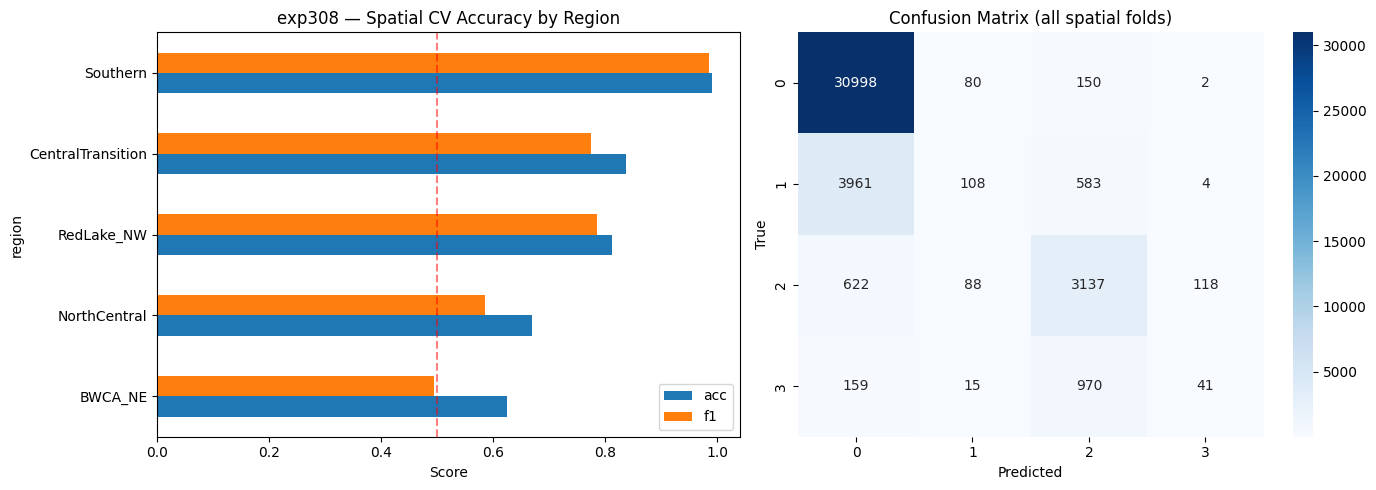


Spatial CV complete. Results: /scratch.global/ocon0444/peat_modeling/05_results/exp308_spatial_cv

Note: spatial CV accuracy is your HONEST out-of-sample performance.
It reflects how well the model extrapolates to unsampled regions.


In [11]:
# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-region accuracy bar
cv_df.sort_values('acc').plot.barh(
    x='region', y=['acc', 'f1'], ax=axes[0])
axes[0].set_title(f'{EXP_TO_EVAL} — Spatial CV Accuracy by Region')
axes[0].set_xlabel('Score')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')

# Confusion matrix across all spatial folds
y_true_arr = np.array(all_y_true)
y_pred_arr = np.array(all_y_pred)
present = sorted(np.unique(y_true_arr))
cm = confusion_matrix(y_true_arr, y_pred_arr, labels=present)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=present, yticklabels=present)
axes[1].set_title('Confusion Matrix (all spatial folds)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/spatial_cv_summary.png', dpi=150)
plt.show()

print(f'\nSpatial CV complete. Results: {RESULTS_DIR}')
print('\nNote: spatial CV accuracy is your HONEST out-of-sample performance.')
print('It reflects how well the model extrapolates to unsampled regions.')